# 📈 Capital Asset Pricing Model (CAPM) — Expected Return Analysis

**Author:** Srinivas  
**Stock:** Meta Platforms Inc. (META)  
**Benchmark:** S&P 500 (^GSPC)  
**Period:** 2020 – 2024  

---

## What is CAPM?

The **Capital Asset Pricing Model (CAPM)** estimates the expected return of a stock based on its systematic risk (Beta) relative to the market.

$$E(R_i) = R_f + \beta_i \cdot (E(R_m) - R_f)$$

| Symbol | Meaning |
|--------|--------|
| $E(R_i)$ | Expected return of the stock |
| $R_f$ | Risk-free rate (10-Year US Treasury yield) |
| $\beta_i$ | Stock's sensitivity to market movements |
| $E(R_m)$ | Expected market return (S&P 500) |
| $E(R_m) - R_f$ | Market risk premium |

---

## Workflow
1. Fetch historical price data (META + S&P500)
2. Load risk-free rate (10-Year US Treasury)
3. Calculate daily returns and excess returns
4. Run OLS regression to estimate Beta
5. Compute CAPM expected return
6. Compare with actual return → calculate Alpha

## 1. Imports

In [3]:
import re
from io import StringIO
import requests
import pandas as pd
import numpy as np
import pandas_datareader as pdr
from datetime import datetime
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import yfinance as yf

## 2. Fetch Historical Price Data

We download **adjusted closing prices** for:
- `META` — Meta Platforms Inc.
- `^GSPC` — S&P 500 Index (market benchmark)

Period: **January 2020 – December 2024**

In [6]:
def get_historical_Data(tickers, start="2020-01-01", end="2025-01-01"):
    """
    Returns a DataFrame of adjusted closing prices for given tickers.
    """
    data = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=True,   # gives adjusted close directly
        progress=False
    )["Close"]

    # If single ticker, yf returns a Series — convert to DataFrame
    if isinstance(data, pd.Series):
        data = data.to_frame()
        data.columns = tickers if isinstance(tickers, list) else [tickers]

    return data


## 3. Load Risk-Free Rate (10-Year US Treasury Yield)

The **DGS10** series from FRED represents the 10-Year US Treasury Constant Maturity Rate — used as a proxy for the risk-free rate $R_f$.

> **Download:** https://fred.stlouisfed.org/series/DGS10 → Save as `DGS10.csv`

In [9]:
T_rate = pd.read_csv('/Users/srinivas/Desktop/DGS10.csv')
T_rate

,DATE,DGS10
0,2010-11-15,2.92
1,2010-11-16,2.85
2,2010-11-17,2.89
3,2010-11-18,2.90
4,2010-11-19,2.88
...,...,...
2604,2020-11-06,0.83
2605,2020-11-09,0.96
2606,2020-11-10,0.98
2607,2020-11-11,.


In [11]:
T_rate['DATE'] = pd.to_datetime(T_rate['DATE'], format = "%Y-%m-%d").dt.strftime('%m-%d-%Y')

In [13]:
T_rate

,DATE,DGS10
0,11-15-2010,2.92
1,11-16-2010,2.85
2,11-17-2010,2.89
3,11-18-2010,2.90
4,11-19-2010,2.88
...,...,...
2604,11-06-2020,0.83
2605,11-09-2020,0.96
2606,11-10-2020,0.98
2607,11-11-2020,.


In [15]:
ticks = ['META', '^GSPC']
d = get_historical_Data(ticks)

In [16]:
print(d.shape)
d

(1258, 2)


Ticker,META,^GSPC
Date,,
2020-01-02,208.146576,3257.850098
2020-01-03,207.045227,3234.850098
2020-01-06,210.944641,3246.280029
2020-01-07,211.401016,3237.179932
2020-01-08,213.544205,3253.050049
...,...,...
2024-12-24,605.321350,6040.040039
2024-12-26,600.938904,6037.589844
2024-12-27,597.413086,5970.839844


In [17]:
d = d.drop(columns=['level_0', 'index'], errors='ignore')
print(d.head())

Ticker            META        ^GSPC
Date                               
2020-01-02  208.146576  3257.850098
2020-01-03  207.045227  3234.850098
2020-01-06  210.944641  3246.280029
2020-01-07  211.401016  3237.179932
2020-01-08  213.544205  3253.050049


## 4. Merge Stock Data with Risk-Free Rate

In [19]:
d = d.reset_index()
d = d.rename(columns={'Date': 'DATE'})

# Standardize both date formats
T_rate['DATE'] = pd.to_datetime(T_rate['DATE'], format='mixed').dt.strftime('%m/%d/%Y')
d['DATE'] = pd.to_datetime(d['DATE'], format='mixed').dt.strftime('%m/%d/%Y')

# Merge
data = pd.merge(left=T_rate, right=d, on='DATE')
data = data.rename(columns={"DGS10": "10_year_rate"})
print(data.shape)
print(data.head())

(220, 4)
         DATE 10_year_rate        META        ^GSPC
0  01/02/2020         1.88  208.146576  3257.850098
1  01/03/2020         1.80  207.045227  3234.850098
2  01/06/2020         1.81  210.944641  3246.280029
3  01/07/2020         1.83  211.401016  3237.179932
4  01/08/2020         1.87  213.544205  3253.050049


In [24]:
data['META_Daily_Returns'] = data['META'].pct_change()
data['SP500_Daily_Returns']=data['^GSPC'].pct_change()

In [26]:
data

,DATE,10_year_rate,META,^GSPC,META_Daily_Returns,SP500_Daily_Returns
0,01/02/2020,1.88,208.146576,3257.850098,NaN,NaN
1,01/03/2020,1.80,207.045227,3234.850098,-0.005291,-0.007060
2,01/06/2020,1.81,210.944641,3246.280029,0.018834,0.003533
3,01/07/2020,1.83,211.401016,3237.179932,0.002163,-0.002803
4,01/08/2020,1.87,213.544205,3253.050049,0.010138,0.004902
...,...,...,...,...,...,...
215,11/06/2020,0.83,291.125427,3509.439941,-0.004310,-0.000288
216,11/09/2020,0.96,276.599365,3550.500000,-0.049896,0.011700
217,11/10/2020,0.98,270.308716,3545.530029,-0.022743,-0.001400
218,11/11/2020,.,274.327209,3572.659912,0.014866,0.007652


## 5. Calculate Daily Returns & Excess Returns

**Daily Return:** $r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$

**Excess Return:** Return above the risk-free rate
$$\text{Excess Return} = r_t - R_f$$

In [29]:
# Clean the 10_year_rate column
data['10_year_rate'] = pd.to_numeric(data['10_year_rate'], errors='coerce')  # '.' becomes NaN
data['10_year_rate'] = data['10_year_rate'].ffill()  # fill NaN with previous value

# Now calculate excess returns
data = data[1:]
data['Excess_Return_META'] = data['META_Daily_Returns'] - data['10_year_rate'] / 100
data['Excess_Return_SP500'] = data['SP500_Daily_Returns'] - data['10_year_rate'] / 100

print(data.head())

         DATE  10_year_rate        META        ^GSPC  META_Daily_Returns  \
1  01/03/2020          1.80  207.045227  3234.850098           -0.005291   
2  01/06/2020          1.81  210.944641  3246.280029            0.018834   
3  01/07/2020          1.83  211.401016  3237.179932            0.002163   
4  01/08/2020          1.87  213.544205  3253.050049            0.010138   
5  01/09/2020          1.85  216.600220  3274.699951            0.014311   

   SP500_Daily_Returns  Excess_Return_META  Excess_Return_SP500  
1            -0.007060           -0.023291            -0.025060  
2             0.003533            0.000734            -0.014567  
3            -0.002803           -0.016137            -0.021103  
4             0.004902           -0.008562            -0.013798  
5             0.006655           -0.004189            -0.011845  


/var/folders/x1/0mm806rs3zb6fk8918sb9cdm0000gn/T/ipykernel_6234/3473529553.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Excess_Return_META'] = data['META_Daily_Returns'] - data['10_year_rate'] / 100
/var/folders/x1/0mm806rs3zb6fk8918sb9cdm0000gn/T/ipykernel_6234/3473529553.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Excess_Return_SP500'] = data['SP500_Daily_Returns'] - data['10_year_rate'] / 100


In [31]:
data = data[1:]

data['Excess_Return_META'] = data['META_Daily_Returns'] - data['10_year_rate'].astype('float')/100
data['Excess_Return_SP500'] = data['SP500_Daily_Returns'] - data['10_year_rate'].astype('float')/100

In [33]:
data

,DATE,10_year_rate,META,^GSPC,META_Daily_Returns,SP500_Daily_Returns,Excess_Return_META,Excess_Return_SP500
2,01/06/2020,1.81,210.944641,3246.280029,0.018834,0.003533,0.000734,-0.014567
3,01/07/2020,1.83,211.401016,3237.179932,0.002163,-0.002803,-0.016137,-0.021103
4,01/08/2020,1.87,213.544205,3253.050049,0.010138,0.004902,-0.008562,-0.013798
5,01/09/2020,1.85,216.600220,3274.699951,0.014311,0.006655,-0.004189,-0.011845
6,01/10/2020,1.83,216.362091,3265.350098,-0.001099,-0.002855,-0.019399,-0.021155
...,...,...,...,...,...,...,...,...
215,11/06/2020,0.83,291.125427,3509.439941,-0.004310,-0.000288,-0.012610,-0.008588
216,11/09/2020,0.96,276.599365,3550.500000,-0.049896,0.011700,-0.059496,0.002100
217,11/10/2020,0.98,270.308716,3545.530029,-0.022743,-0.001400,-0.032543,-0.011200
218,11/11/2020,0.98,274.327209,3572.659912,0.014866,0.007652,0.005066,-0.002148


## 6. OLS Regression → Estimate Beta

We regress META's excess returns on S&P500's excess returns:

$$\text{Excess Return}_{META} = \alpha + \beta \cdot \text{Excess Return}_{S\&P500} + \epsilon$$

- **Slope ($\beta$):** Systematic risk — how much META moves per 1% market move
- **Intercept ($\alpha$):** Jensen's Alpha — excess return not explained by market risk

In [36]:
results = smf.ols('Excess_Return_META ~ Excess_Return_SP500', data = data).fit()

In [38]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     Excess_Return_META   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                     288.6
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.15e-41
Time:                        09:04:06   Log-Likelihood:                 541.32
No. Observations:                 218   AIC:                            -1079.
Df Residuals:                     216   BIC:                            -1072.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.0010    

## 7. S&P 500 Geometric Average Annual Return (2020–2024)

We use the **geometric mean** (not arithmetic) because it accounts for compounding:

$$\bar{R}_m = \left(\prod_{t=1}^{n}(1+r_t)\right)^{1/n} - 1$$

In [41]:
# Use ^GSPC from your existing data
sp500 = yf.download('^GSPC', start='2015-01-01', end='2021-01-01', 
                    auto_adjust=True, progress=False)['Close']

# Calculate annual returns
annual_returns = sp500.resample('YE').last().pct_change().dropna()
print(annual_returns)

# Build the geometric mean properly
multipliers = (1 + annual_returns).values
cumulative = multipliers.prod()
n = len(multipliers)
geo_mean = cumulative ** (1/n) - 1

print(f"\nYears: {n}")
print(f"Multipliers: {multipliers.round(4)}")
print(f"Geometric Average Annual Return: {geo_mean:.4%}")

Ticker         ^GSPC
Date                
2016-12-31  0.095350
2017-12-31  0.194200
2018-12-31 -0.062373
2019-12-31  0.288781
2020-12-31  0.162589

Years: 5
Multipliers: [[1.0954]
 [1.1942]
 [0.9376]
 [1.2888]
 [1.1626]]
Geometric Average Annual Return: 12.9414%


## 8. CAPM Expected Return

$$E(R_{META}) = R_f + \beta \cdot (E(R_m) - R_f)$$

In [44]:
Beta = 0.9950

average_risk_free_rate = data['10_year_rate'].astype('float').mean() /100
#average_return_SP500 = (1.311 * (1-.0441) * (1.2194) * (1.1193) * (1.0131) * (1.1381)) ** (1/5)-1
average_return_SP500 = (1.0954 * 1.1942 * 0.9376 * 1.2888 * 1.1626) ** (1/5) - 1

expected_return_META = average_risk_free_rate + Beta * (average_return_SP500 - average_risk_free_rate)

print(f"Average Risk Free Rate:     {average_risk_free_rate:.4%}")
print(f"Average Return S&P500:      {average_return_SP500:.4%}")
print(f"Expected Return META:{expected_return_META:.4%}")

Average Risk Free Rate:     0.8771%
Average Return S&P500:      12.9423%
Expected Return META:12.8820%


## 10. Visualisation

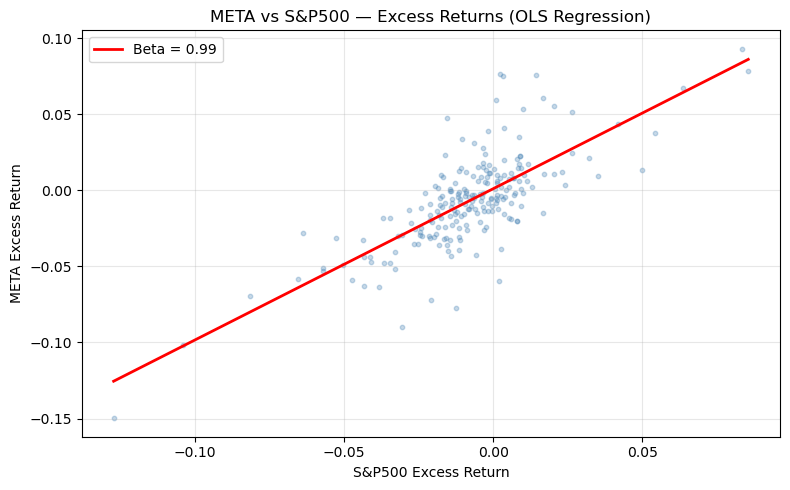

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(data['Excess_Return_SP500'], data['Excess_Return_META'],
           alpha=0.3, s=10, color='steelblue')

x = np.linspace(data['Excess_Return_SP500'].min(), data['Excess_Return_SP500'].max(), 100)
ax.plot(x, results.params['Intercept'] + Beta * x, color='red', linewidth=2, label=f'Beta = {Beta:.2f}')

ax.set_title('META vs S&P500 — Excess Returns (OLS Regression)')
ax.set_xlabel('S&P500 Excess Return')
ax.set_ylabel('META Excess Return')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('capm_results.png', dpi=150, bbox_inches='tight')
plt.show()